# Preparation of Suo data for Ablation

In [2]:
0

0

In [42]:
import sys
working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)

import logging
import subprocess
import gc
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
import pickle

sc.settings.verbose = 3

In [4]:
from sctram.generate.real import sc_suo_developmental_complete

In [55]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [68]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"

input_trajectories_path = os.path.join(dataset_dir, f"adata_suo_input_haematopoeitic_lineage.pkl")
with open(input_trajectories_path, "rb") as _file:
    lit = pickle.load(_file)

In [70]:
adata = sc_suo_developmental_complete(dataset_dir=dataset_dir)
adata = adata[adata.obs.LVL0 == "Haematopoeitic_lineage"]
adata

2025-04-21 04:51:09.939 | WARNING  | sctram.generate.real._download:download_dataset:105 - File PosixPath('/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/suo_developmental_complete.h5ad') already exists. Skipping download.


View of AnnData object with n_obs × n_vars = 561947 × 8192
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'rank_genes_groups'
    obsm: 'Unintegrated', 'X_pca', 'harmony', 'invae', 'scanvi', 'scvi', 'tardis_1', 'tardis_2'

In [84]:
def smart_subsample(adata, group_key="LVL3", max_cells_per_group=500, random_state=0):
    """
    Subsample overrepresented groups to 'max_cells_per_group' cells,
    retain all cells from underrepresented groups.
    """
    np.random.seed(random_state)
    groups = adata.obs[group_key]
    indices_to_keep = []

    for group in groups.unique():
        group_indices = adata.obs.index[groups == group].tolist()
        if len(group_indices) > max_cells_per_group:
            selected = np.random.choice(group_indices, max_cells_per_group, replace=False)
            indices_to_keep.extend(selected)
        else:
            indices_to_keep.extend(group_indices)

    return adata[indices_to_keep].copy()

In [108]:
adata_subset = smart_subsample(adata, max_cells_per_group=2000)
adata_subset

AnnData object with n_obs × n_vars = 117258 × 8192
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'rank_genes_groups'
    obsm: 'Unintegrated', 'X_pca', 'harmony', 'invae', 'scanvi', 'scvi', 'tardis_1', 'tardis_2'

In [109]:
adata_sl = ad.AnnData(X=adata_subset.obsm['scvi'], obs=adata_subset.obs)
sc.pp.neighbors(adata_sl)
sc.tl.umap(adata_sl)
adata_sl

AnnData object with n_obs × n_vars = 117258 × 24
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'

In [105]:
trajectory_list = ['early_b_cells', 'erythroid_megakaryocyte', 'granulocyte_monocytes'] 

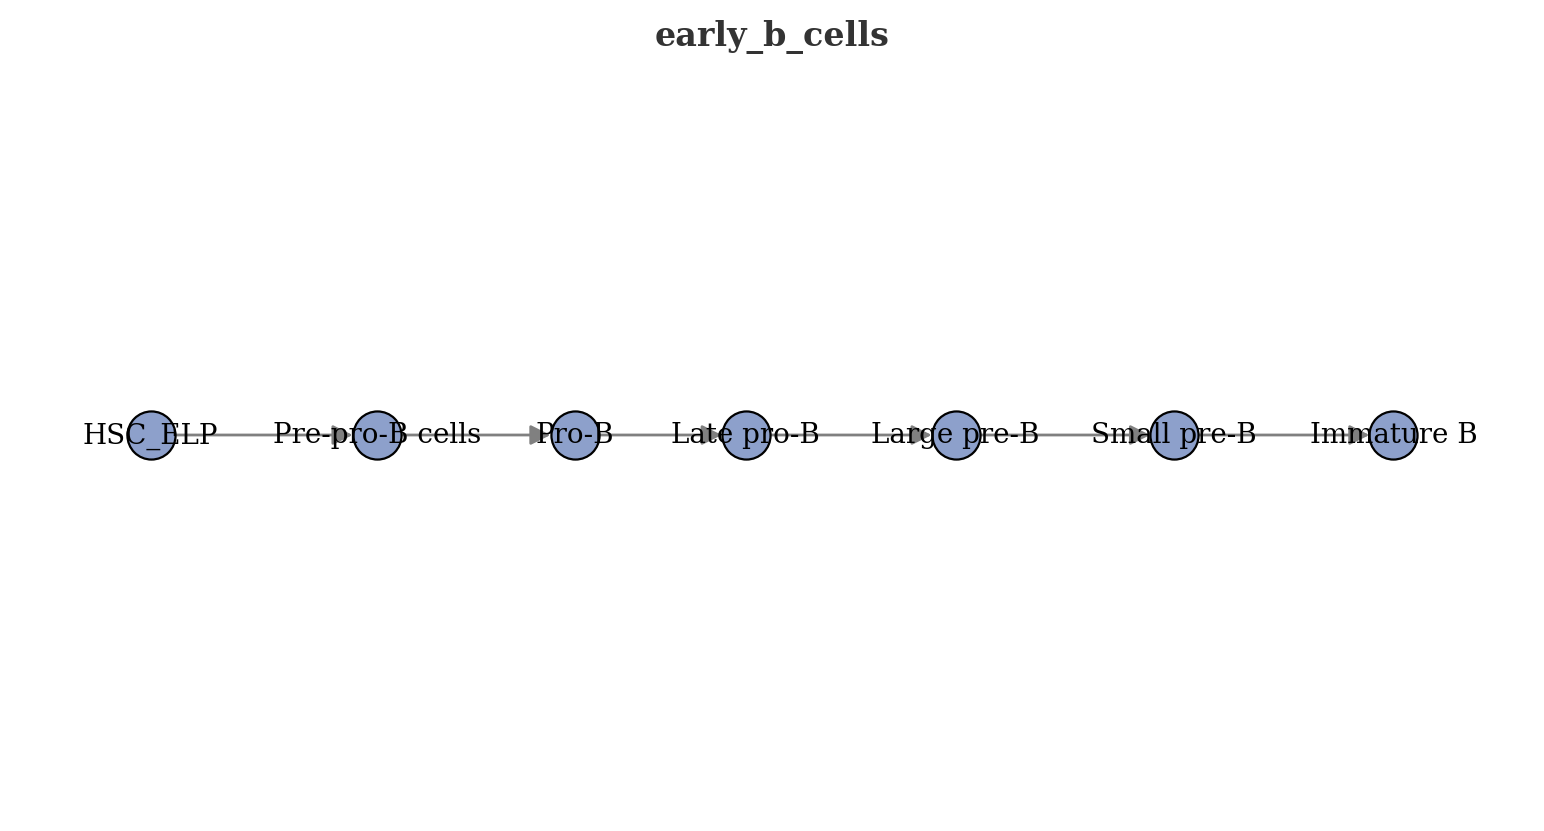

/home/icb/kemal.inecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


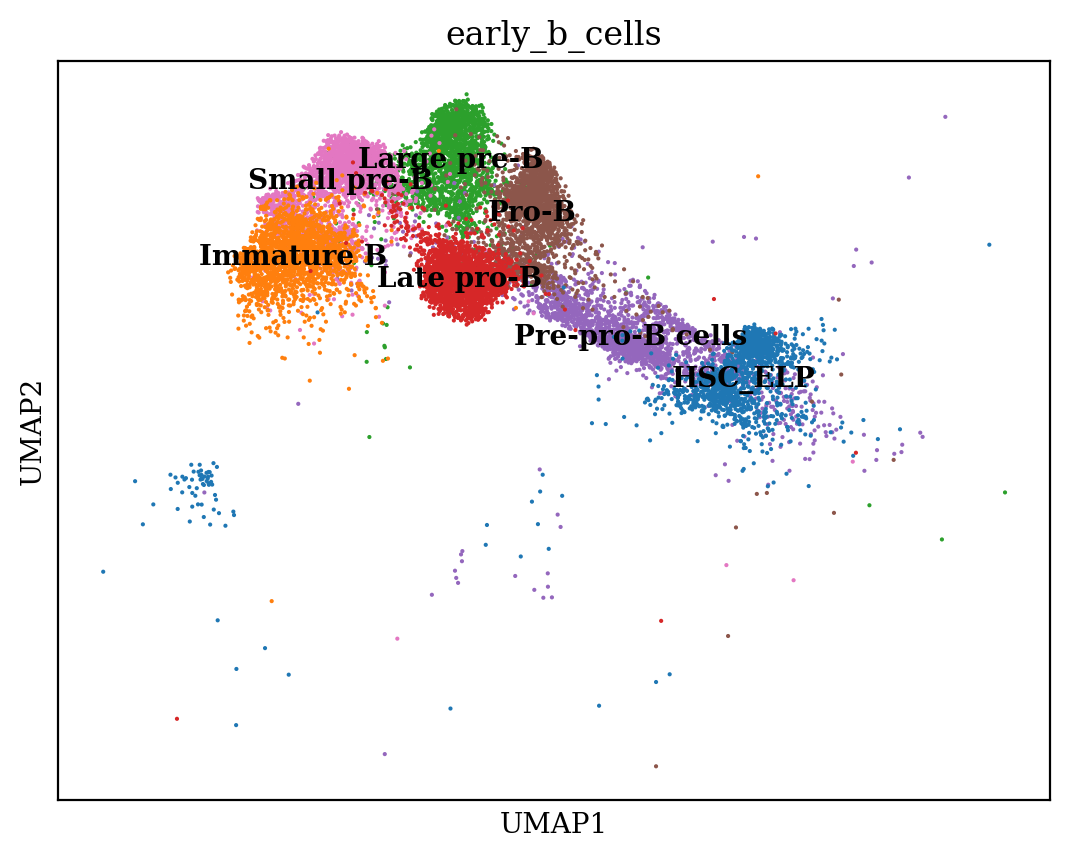

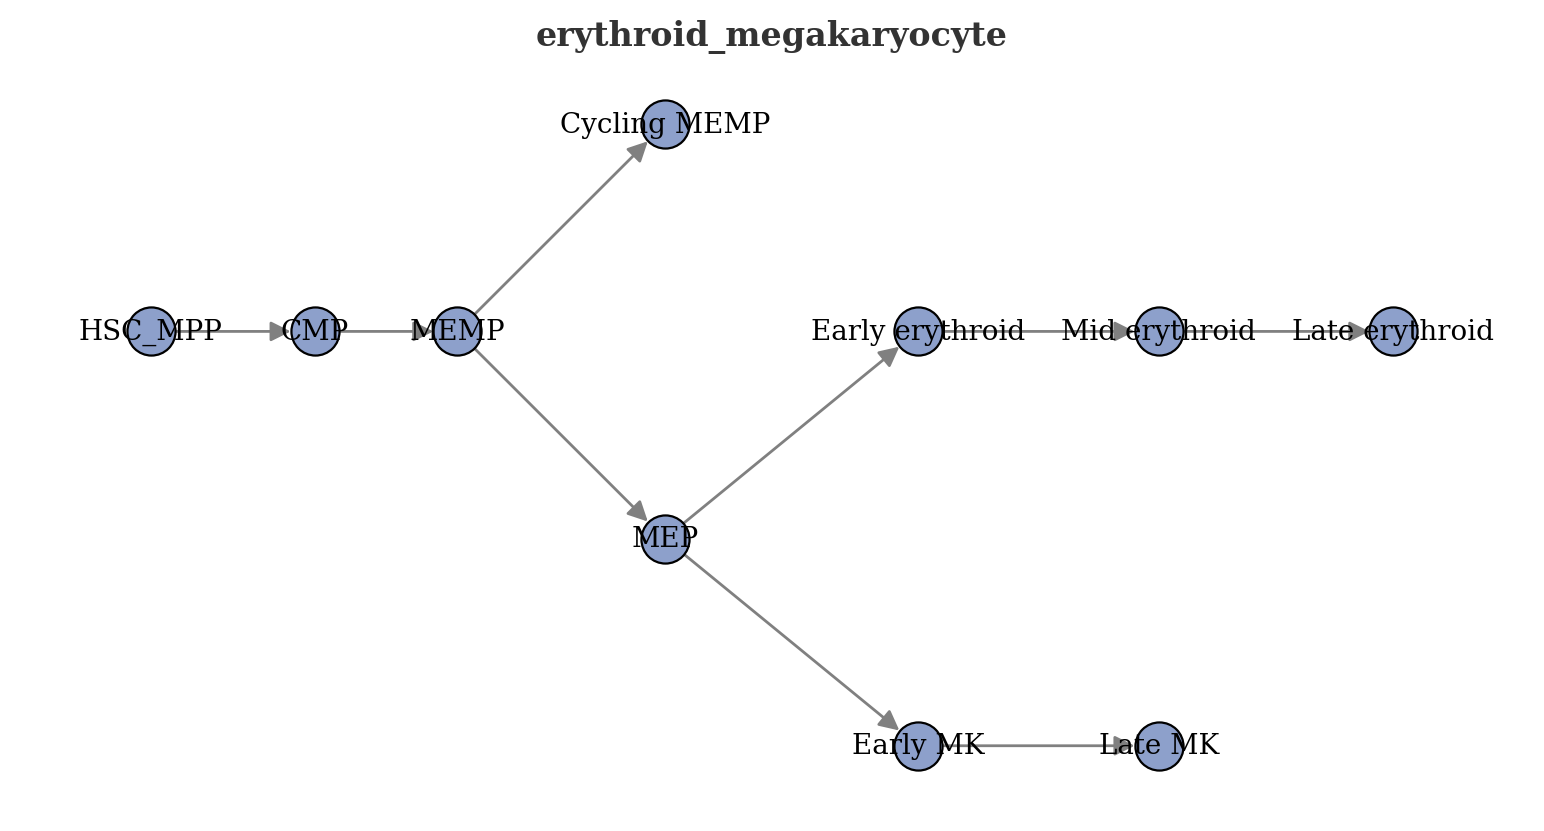

/home/icb/kemal.inecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


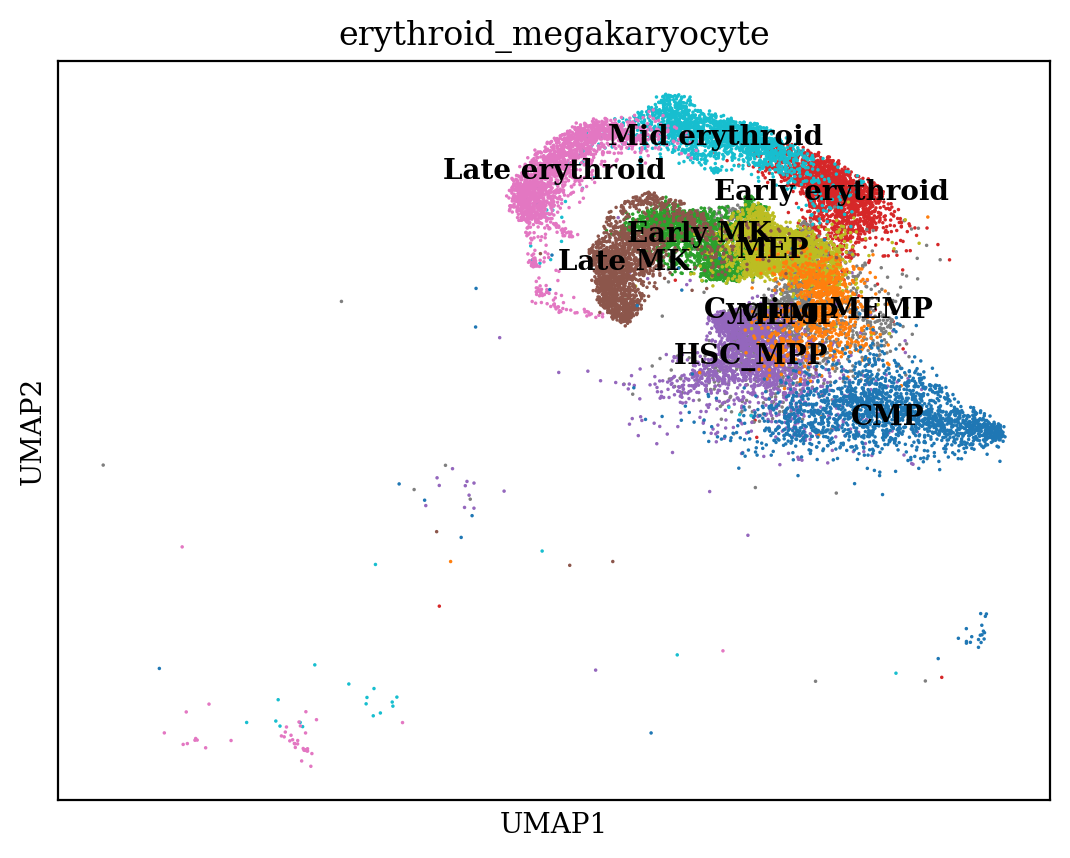

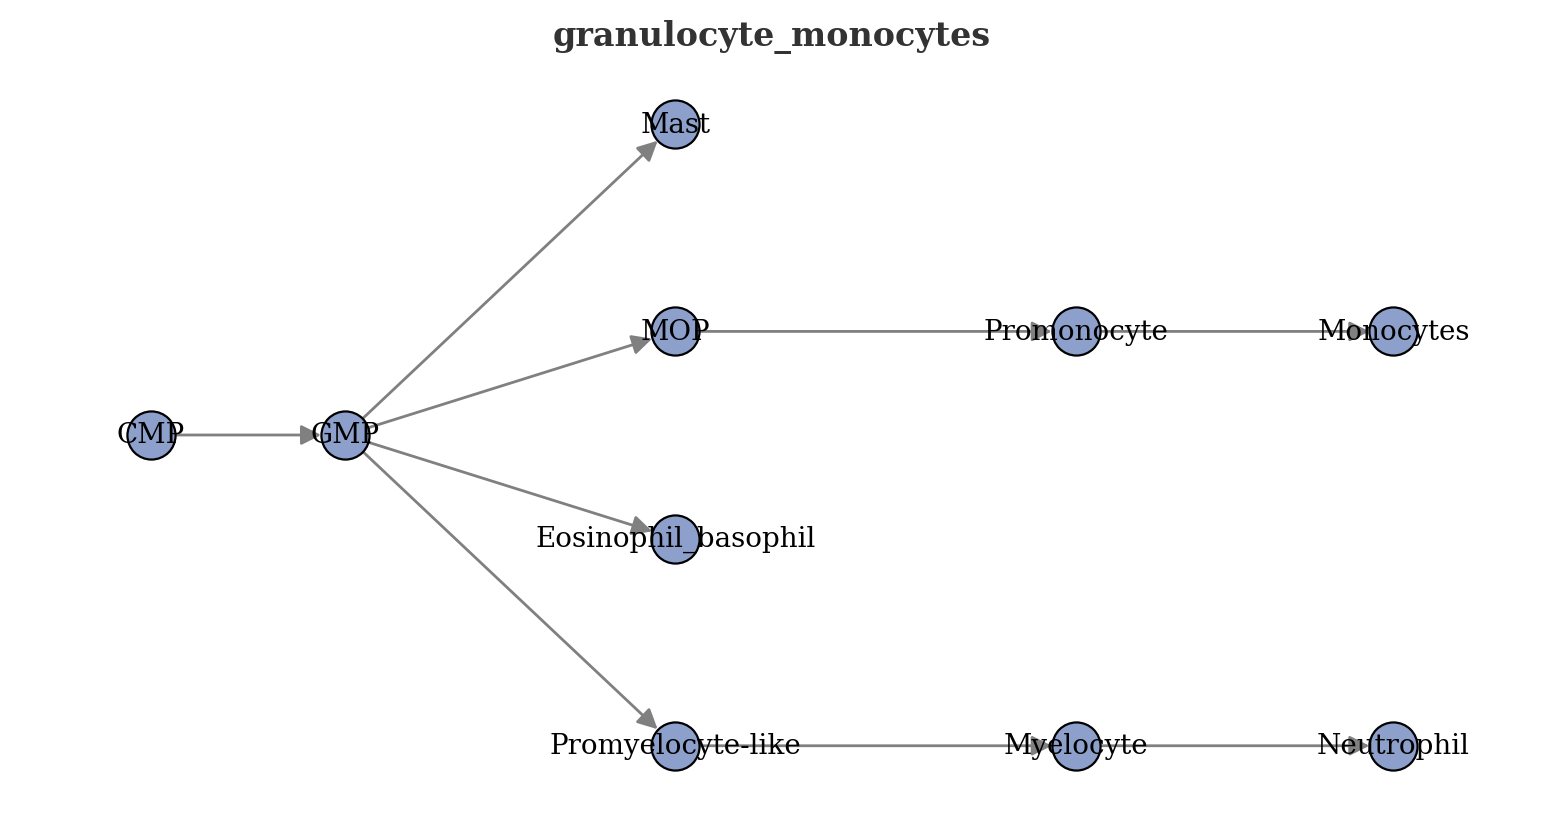

/home/icb/kemal.inecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


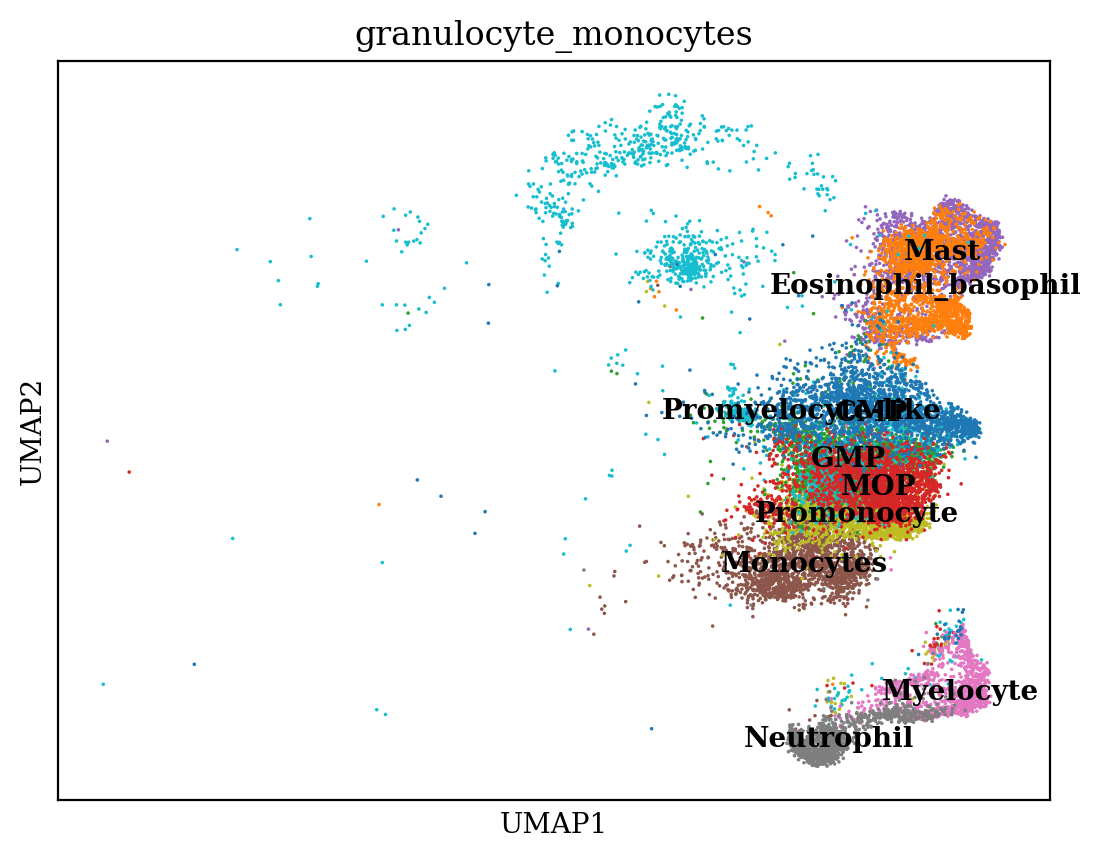

In [107]:
for i in trajectory_list:
    traj = lit.get_trajectory(i, False)
    traj.plot_trajectory()
    cells = set(traj.nodes())
    adata_ssl = adata_sl[adata_sl.obs.LVL3.isin(cells)]
    sc.pl.umap(adata_ssl, color=["LVL3"], legend_loc="on data", title=i, )

In [111]:
adata_subset_path = os.path.join(dataset_dir, "suo_subset_ablation.h5ad")
adata_subset.write_h5ad(adata_subset_path)

In [110]:
1

1